# PerceptionMetrics basic tutorial
PerceptionMetrics provides a unified evaluation pipeline for perception models, currently focused in semantic segmentation in unstructured environments. For this basic tutorial, we are going to evaluate an image segmentation model on RELLIS-3D test dataset.

## Download required data (SUB-SAMPLE - only 20 images for fast first run)

tutorial_image_segmentation_sample.ipynb contains the links to the larger RELLIS-3D dataset (approx. 10 GB)

#### Dataset (RELLIS-3D)
📝 [Paper](https://arxiv.org/abs/2011.12954)
🧑‍💻️ [Repo](https://github.com/unmannedlab/RELLIS-3D)

In [1]:
!pip install gdown


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
!mkdir -p local/data_subsample && cd local/data_subsample

# Download
!gdown 1zI5yeKeOptwUzSQc1w1_uaDwe3vghwqS -O local/data_subsample/  # split
!gdown 1tTUbKHU90KE2r2iDjRqW0RaVR4vzXKgy -O local/data_subsample/  # ontology
!gdown 1-xUv_Xmg93BjJ94XCNJMt6SvkTtLNA9D -O local/data_subsample/  # labels
!gdown 1gAksuWfWplOQLDZ_bMXp7k5t5uHeYO8x -O local/data_subsample/  # images

Downloading...
From: https://drive.google.com/uc?id=1zI5yeKeOptwUzSQc1w1_uaDwe3vghwqS
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/Rellis_3D_image_split.zip
100%|███████████████████████████████████████████| 859/859 [00:00<00:00, 741kB/s]
Downloading...
From: https://drive.google.com/uc?id=1tTUbKHU90KE2r2iDjRqW0RaVR4vzXKgy
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/Rellis_3D_ontology.zip
100%|██████████████████████████████████████| 18.4k/18.4k [00:00<00:00, 13.0MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-xUv_Xmg93BjJ94XCNJMt6SvkTtLNA9D
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/Rellis_3D_pylon_camera_node_label_id.zip
100%|████████████████████████████████████████| 454k/454k [00:00<00:00, 19.8MB/s]
Downloading...
From: https://drive.google.com/uc?id=1gAksuWfWplOQLDZ_bMXp7k5t5uHeYO8x
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionM

In [3]:
# Unzip
!unzip -o local/data_subsample/Rellis_3D_image_split.zip -d local/data_subsample/rellis3d/
!unzip -o local/data_subsample/Rellis_3D_ontology.zip -d local/data_subsample/rellis3d/
!unzip -o local/data_subsample/Rellis_3D_pylon_camera_node_label_id.zip -d local/data_subsample/rellis3d/
!unzip -o local/data_subsample/Rellis_3D_pylon_camera_node.zip -d local/data_subsample/rellis3d/

Archive:  local/data_subsample/Rellis_3D_image_split.zip
  inflating: local/data_subsample/rellis3d/val.lst  
  inflating: local/data_subsample/rellis3d/test.lst  
  inflating: local/data_subsample/rellis3d/train.lst  
Archive:  local/data_subsample/Rellis_3D_ontology.zip
  inflating: local/data_subsample/rellis3d/Rellis_3D_ontology/ontology.yaml  
  inflating: local/data_subsample/rellis3d/Rellis_3D_ontology/ontology.csv  
  inflating: local/data_subsample/rellis3d/Rellis_3D_ontology/ontology.png  
Archive:  local/data_subsample/Rellis_3D_pylon_camera_node_label_id.zip
  inflating: local/data_subsample/rellis3d/Rellis-3D/00000/pylon_camera_node_label_id/frame000314-1581624684_149.png  
  inflating: local/data_subsample/rellis3d/Rellis-3D/00000/pylon_camera_node_label_id/frame001709-1581624823_650.png  
  inflating: local/data_subsample/rellis3d/Rellis-3D/00000/pylon_camera_node_label_id/frame000326-1581624685_350.png  
  inflating: local/data_subsample/rellis3d/Rellis-3D/00000/pylon_c

#### Model (PyTorch)

In [4]:
# Download
!gdown 1Uqy4BU_-gwzeRRmo-_jTtYNDV88Sick- -O local/data_subsample/image_segmentation_model.pth            # model
!gdown 1suSJOahLq13SCZ3XJ3mghQIZAKkdG5E1 -O local/data_subsample/image_segmentation_model_cfg.json       # configuration
!gdown 19cRKEL72uuyRRmxPw5ev68PvCx0bBfIy -O local/data_subsample/image_segmentation_model_ontology.json  # ontology

Downloading...
From (original): https://drive.google.com/uc?id=1Uqy4BU_-gwzeRRmo-_jTtYNDV88Sick-
From (redirected): https://drive.google.com/uc?id=1Uqy4BU_-gwzeRRmo-_jTtYNDV88Sick-&confirm=t&uuid=7a5d9f07-4b91-4d0f-92b3-db0a1517eb29
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/image_segmentation_model.pth
100%|████████████████████████████████████████| 159M/159M [00:02<00:00, 73.4MB/s]
Downloading...
From: https://drive.google.com/uc?id=1suSJOahLq13SCZ3XJ3mghQIZAKkdG5E1
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/image_segmentation_model_cfg.json
100%|███████████████████████████████████████████| 288/288 [00:00<00:00, 670kB/s]
Downloading...
From: https://drive.google.com/uc?id=19cRKEL72uuyRRmxPw5ev68PvCx0bBfIy
To: /Users/ioanacalangiu/Documents/GitHub/PerceptionMetrics/examples/local/data_subsample/image_segmentation_model_ontology.json
100%|██████████████████████████████████████| 2.31k/2.31k [00:

## Init dataset and model objects

In [5]:
from perceptionmetrics.datasets import Rellis3DImageSegmentationDataset
from perceptionmetrics.models import TorchImageSegmentationModel

dataset = Rellis3DImageSegmentationDataset(
    dataset_dir="local/data_subsample/rellis3d/Rellis-3D",
    split_dir="local/data_subsample/rellis3d",
    ontology_fname="local/data_subsample/rellis3d/Rellis_3D_ontology/ontology.yaml",
)

model = TorchImageSegmentationModel(
    model="local/data_subsample/image_segmentation_model.pth",
    model_cfg="local/data_subsample/image_segmentation_model_cfg.json",
    ontology_fname="local/data_subsample/image_segmentation_model_ontology.json",
)

2026-07-14 13:17:10.040091: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Samples retrieved: 20 / 20


## Inference

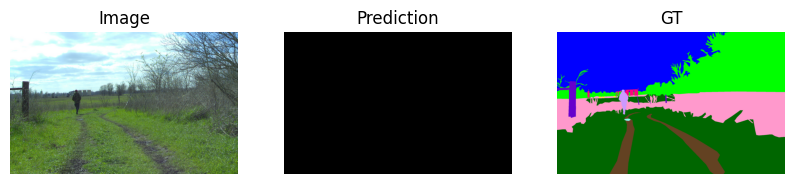

In [6]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image

from perceptionmetrics.utils import conversion as uc

image_fname = dataset.dataset["image"].iloc[0]
image = Image.open(image_fname)

label_fname = dataset.dataset["label"].iloc[0]
label = Image.open(label_fname)
label = uc.label_to_rgb(label, dataset.ontology)

pred = model.predict(image)
pred = uc.label_to_rgb(pred, model.ontology)
pred = pred.resize(label.size)

plt.figure(figsize=(10, 10))
plt.subplot(131), plt.title("Image"), plt.imshow(np.array(image)), plt.axis("off")
plt.subplot(132), plt.title("Prediction"), plt.imshow(np.array(pred)), plt.axis("off")
plt.subplot(133), plt.title("GT"), plt.imshow(np.array(label)), plt.axis("off")
plt.show()

## Evaluation

In [8]:
results = model.eval(dataset, split="test")
display(results)

100%|██████████| 5/5 [01:16<00:00, 15.40s/it]
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/perceptionmetrics/utils/segmentation_metrics.py:147: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/perceptionmetrics/utils/segmentation_metrics.py:164: RuntimeWarning: invalid value encountered in divide
  return np.where(denominator > 0, tp / denominator, np.nan)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/perceptionmetrics/utils/segmentation_metrics.py:258: RuntimeWarning: Mean of empty slice
  return float(np.nanmean(metric(per_class=True)))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/perceptionmetrics/utils/segmentation_metrics.py:222: RuntimeWarning: invalid value encountered in divide
  return np.where(union > 0, tp / union, np.nan)
/Library

,void,dirt,grass,tree,pole,water,sky,vehicle,object,asphalt,...,person,fence,bush,concrete,barrier,puddle,mud,rubble,macro,micro
tp,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,NaN,NaN
fp,421340.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0000,NaN,NaN
fn,0.0,0.0,0.0,95531.000000,103427.000000,0.0,0.0,112198.000000,48.000000,1521.00000,...,0.0,0.0,0.0,0.0,0.0,0.0,1342.000000,107273.0000,NaN,NaN
tn,0.0,421340.0,421340.0,325809.000000,317913.000000,421340.0,421340.0,309142.000000,421292.000000,419819.00000,...,421340.0,421340.0,421340.0,421340.0,421340.0,421340.0,419998.000000,314067.0000,NaN,NaN
precision,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
recall,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0000,0.0,0.0
accuracy,0.0,1.0,1.0,0.773269,0.754528,1.0,1.0,0.733711,0.999886,0.99639,...,1.0,1.0,1.0,1.0,1.0,1.0,0.996815,0.7454,0.9,0.9
f1_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
iou,0.0,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0000,0.0,0.0
dice_score,0.0,NaN,NaN,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.00000,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.0000,0.0,0.0
